# Import dataset

In [46]:
import sys
print(sys.executable)

/Users/nicole/data-training/.venv/bin/python


In [47]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 
import numpy as np
import json

In [48]:
# read bigquery data into pandas dataframe
import pandas as pd

df = pd.read_gbq(
    """
    SELECT  *
    FROM `jr-data-training.cafe.cafe-sales`
    --- LIMIT 10
  """,
    project_id="jr-data-training",
    location="australia-southeast1",
)

/var/folders/03/kg6152lx62g3z5rhmtm47_c80000gn/T/ipykernel_92489/1097260367.py:4: FutureWarning:

read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq



# Evaluation of the average revenue per customer


Using RFM analysis to divide customers into different segments:

- Recency: How recently has the customer made a transaction with us
- Frequency: How frequent is the customer in ordering/buying some product from us
- Monetary: How much does the customer spend on purchasing products from us.

In [49]:
# Create a RFM table
rfm_df = df.groupby('customer_id').agg(
    Recency=('date_created', lambda x: (df['date_created'].max() - x.max()).days),
    Frequency=('date_created', 'count'),
    Monetary=('total', 'sum')
).reset_index()

## Data Pre-processing

In [50]:
fig = px.histogram(rfm_df, x='Recency', title='Recency Distribution', nbins=20, histnorm='probability density')
fig.show()

fig = px.histogram(rfm_df, x='Frequency', title='Frequency Distribution', nbins=20, histnorm='probability density')
fig.show()

fig = px.histogram(rfm_df, x='Monetary', title='Monetary Value Distribution', nbins=20, histnorm='probability density')
fig.show()

Based on the graph above, data transformation is needed as all of them are right-skewed form. 

### Data transformation

#### Initial transformation test

In [51]:
from scipy import stats

'''
 Function for experimenting different transformation methods:

    - log transformation
    - square root transformation
    - box-cox transformation Note
    
'''

def analyze_skewness(x):

    fig, ax = plt.subplots(2, 2, figsize=(6, 6))

    # To ensure the data is positive / non-zero
    adjust_x = np.clip(rfm_df[x], 1e-6, None)

    sns.histplot(adjust_x, ax=ax[0, 0], kde=True)
    sns.histplot(np.log(adjust_x), ax=ax[0, 1], kde=True)
    sns.histplot(np.sqrt(adjust_x), ax=ax[1, 0], kde=True)
    sns.histplot(stats.boxcox(adjust_x)[0], ax=ax[1, 1], kde=True)

    plt.tight_layout()
    plt.show()

    skew_coe = adjust_x.skew().round(2)

    print('Log Transform : The skew coefficient of', skew_coe, 'to', np.log(skew_coe))
    print('Square Root Transform : The skew coefficient of', skew_coe, 'to', np.sqrt(skew_coe))
    print('Box-Cox Transform : The skew coefficient of', skew_coe, 'to', pd.Series(stats.boxcox(adjust_x)[0]).skew().round(2))


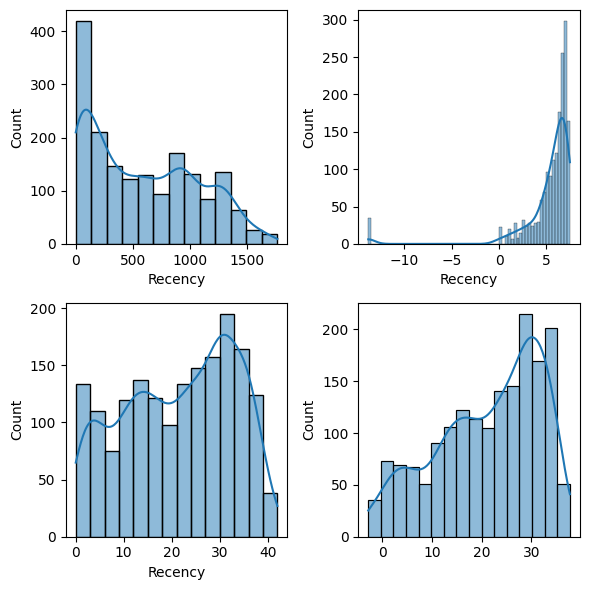

Log Transform : The skew coefficient of 0.4 to -0.916290731874155
Square Root Transform : The skew coefficient of 0.4 to 0.6324555320336759
Box-Cox Transform : The skew coefficient of 0.4 to -0.54


In [52]:
analyze_skewness('Recency')

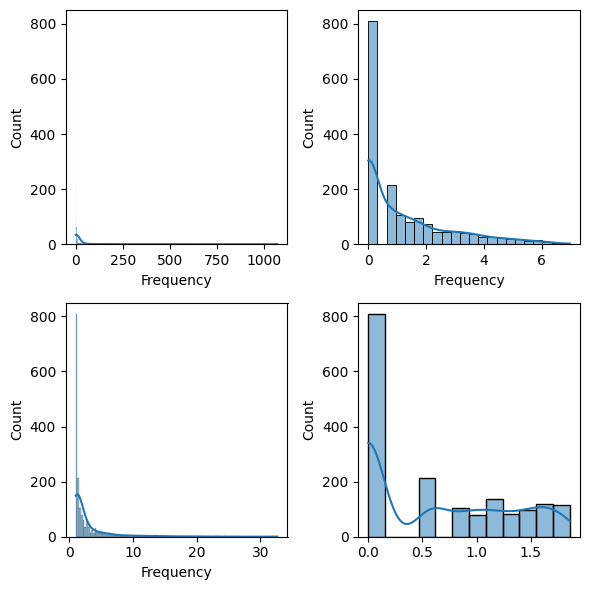

Log Transform : The skew coefficient of 7.47 to 2.010894999144726
Square Root Transform : The skew coefficient of 7.47 to 2.7331300737432898
Box-Cox Transform : The skew coefficient of 7.47 to 0.44


In [53]:
analyze_skewness('Frequency')

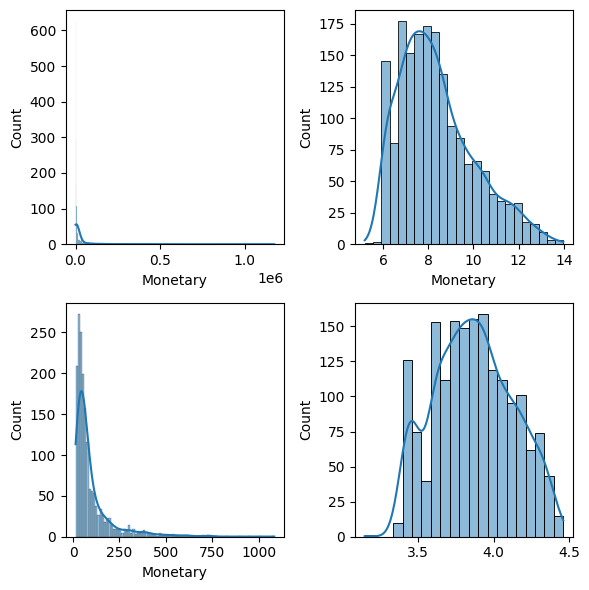

Log Transform : The skew coefficient of 7.35 to 1.9947003132247452
Square Root Transform : The skew coefficient of 7.35 to 2.711088342345192
Box-Cox Transform : The skew coefficient of 7.35 to 0.1


In [54]:
analyze_skewness('Monetary')

The graphs and calculation result showed that the variables with **box-cox transformation** shows a more symmetrical form rather than the other transformations.

#### Adjust the data with Box-Cox Transform

In [55]:
rfm_transformed = pd.DataFrame()

rfm_transformed["R_transformed"] = pd.Series(np.cbrt(rfm_df['Recency'])).values
rfm_transformed["F_transformed"] = stats.boxcox(rfm_df['Frequency'])[0]
rfm_transformed["M_transformed"] = stats.boxcox(rfm_df['Monetary'])[0]

Since the columns dont have the same mean and variance, we have to normalize it using the StandardScaler.

In [56]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

# Fit and Transform The Data
scaler.fit(rfm_transformed)
rfm_normalized = scaler.transform(rfm_transformed)

rfm_normalized = pd.DataFrame(rfm_normalized)

## Data segmentation (K-means)

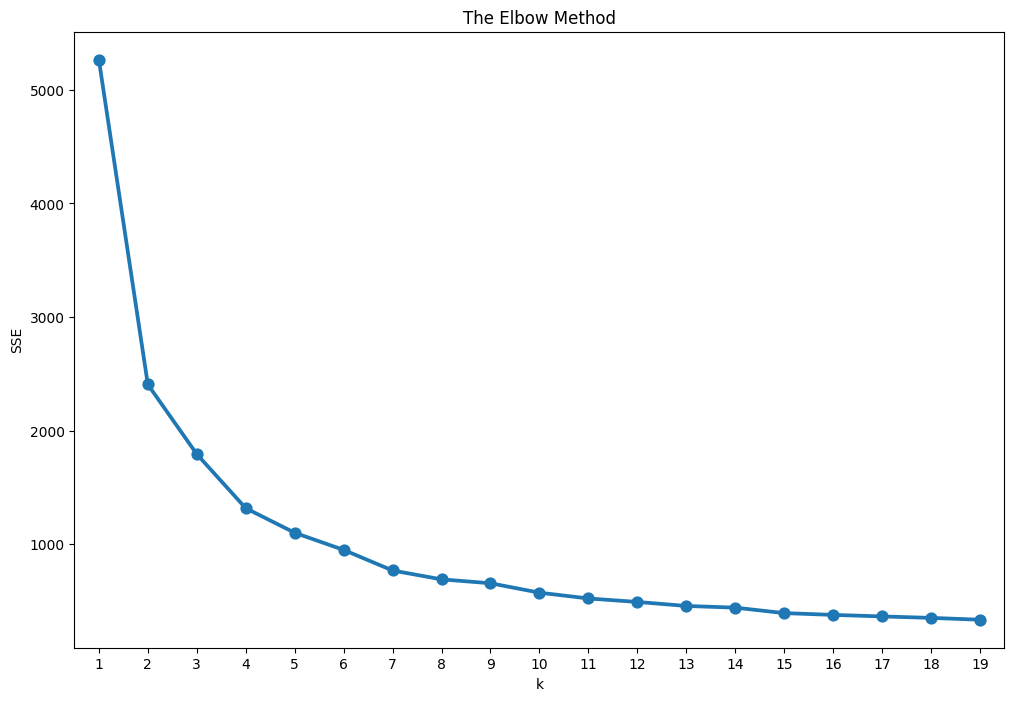

In [57]:
plt.figure(figsize=(12,8))

from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
K = range(1, 20)

distortions = []
inertias = []
mapping1 = {}
sse = {}

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_normalized)
    
    distortions.append(sum(np.min(cdist(rfm_normalized, kmeans.cluster_centers_,
                                        'euclidean'), axis=1)) / rfm_normalized.shape[0])
    inertias.append(kmeans.inertia_)
 
    mapping1[k] = sum(np.min(cdist(rfm_normalized, kmeans.cluster_centers_,
                                   'euclidean'), axis=1)) / rfm_normalized.shape[0]
    
    sse[k] = kmeans.inertia_ # SSE to closest cluster centroid

plt.title('The Elbow Method')
plt.xlabel('k')
plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

In [58]:
for key, val in mapping1.items():
    print(f'{key} : {val}')

1 : 1.6015421359314033
2 : 1.0802583185790864
3 : 0.9261649403759017
4 : 0.8051273938530835
5 : 0.7364774727417666
6 : 0.6707971713856027
7 : 0.6102118329657519
8 : 0.5780007099572635
9 : 0.5620557204504583
10 : 0.5248995620023648
11 : 0.5030583824576222
12 : 0.48377764782372623
13 : 0.46649873215161186
14 : 0.4594771196964336
15 : 0.43016490864073254
16 : 0.41927018091557694
17 : 0.41167304748460726
18 : 0.4030583514504678
19 : 0.39490952222857445


We are going to choose the optimal parameter by observing where the k-value will exhibit a linear trend on the following successive k. Based on the plot above, the k-value of **3** is the ideal hyperparameter for the model as the following k-value tends to have a linear relationship. 

### 3 cluster result

In [60]:
model = KMeans(n_clusters=3, random_state=42)
model.fit(rfm_normalized)

rfm_df["Cluster"] = model.labels_
rfm_df.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':['mean', 'count']}).round(1)

Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         747.5       1.1   1768.9   911
1          67.2      92.4  97523.5   340
2         654.2       9.8  14251.7   504

### Fit the K-means model

In [32]:
# Create the dataframe
df_normalized = pd.DataFrame(rfm_normalized)
df_normalized.rename(columns={0: "Recency", 1: "Frequency", 2: "Monetary"}, errors="raise", inplace=True)
df_normalized['ID'] = rfm_df.index
df_normalized['Cluster'] = model.labels_
df_normalized.head()

,Recency,Frequency,Monetary,ID,Cluster
0,1.541273,0.554607,-0.650036,0,2
1,0.865053,1.697416,1.829686,1,2
2,-0.458680,0.554607,0.303795,2,2
3,1.521836,-0.951542,-0.705106,3,0
4,-0.694743,1.762915,1.783266,4,1


In [35]:
# Melt The Data
df_nor_melt = pd.melt(df_normalized.reset_index(),
                      id_vars=['ID', 'Cluster'],
                      value_vars=['Recency','Frequency','Monetary'],
                      var_name='Attribute',
                      value_name='Value')


In [36]:
df_nor_melt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5265 entries, 0 to 5264
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         5265 non-null   int64  
 1   Cluster    5265 non-null   int32  
 2   Attribute  5265 non-null   object 
 3   Value      5265 non-null   float64
dtypes: float64(1), int32(1), int64(1), object(1)
memory usage: 144.1+ KB


In [37]:
# Aggregate data by each customer
fig3 = df_nor_melt.groupby('Cluster').agg({'ID': lambda x: len(x)}).reset_index()


# Rename columns
fig3.rename(columns={'ID': 'Count'}, inplace=True)
fig3['percent'] = (fig3['Count'] / fig3['Count'].sum()) * 100
fig3['percent'] = fig3['percent'].round(1)

fig3.head()

,Cluster,Count,percent
0,0,2733,51.9
1,1,1020,19.4
2,2,1512,28.7


In [38]:
#Creating a Treemap with Plotly Express
# colors=['#fae588','#f79d65','#f9dc5c','#e8ac65','#e76f51','#ef233c','#b7094c'] #color palette
colors=['#bad0af','#d5e0cf','#f1f1f1','#f1d4d4'] #color palette
import plotly.express as px

fig = px.treemap(fig3, path=['Cluster'],values='Count'
                 , width=800, height=400
                 ,title="Distribution of Cluster")

fig.update_layout(
    treemapcolorway = colors, #defines the colors in the treemap
    margin = dict(t=50, l=25, r=25, b=25))

fig.data[0].textinfo = 'label+text+value+percent root'
fig.show()

<Axes: xlabel='Attribute', ylabel='Value'>

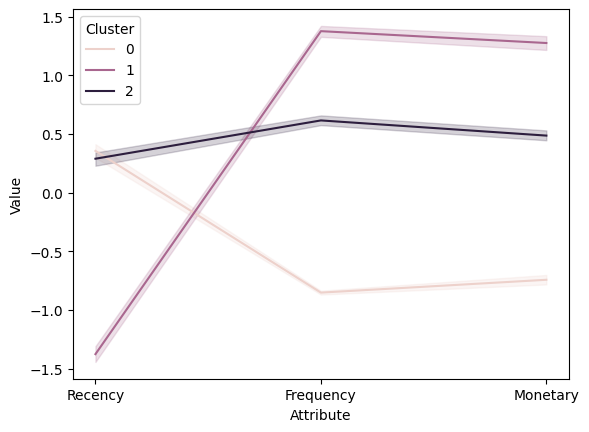

In [40]:
# Visualize it
sns.lineplot(x='Attribute', y='Value', hue='Cluster', data=df_nor_melt)

From the above snake plot, we can see the distribution of recency, frequency, and monetary metric values across the clusters. The clusters seem to be separate from each other, which indicates a good heterogeneous mix of clusters.

### Scatter Plot Comparisons

In [41]:
import plotly.express as px

fig = px.scatter_3d(df_normalized, x='Recency', y='Frequency', z='Monetary',
              color='Cluster')
fig.show()

In [61]:
cluster_avg = rfm_df[['Cluster','Recency','Frequency','Monetary']].groupby(['Cluster']).mean()
population_avg = rfm_df[['Recency','Frequency','Monetary']].head().mean()

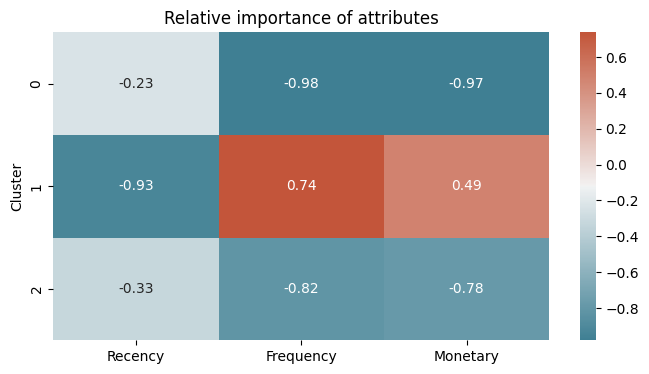

In [76]:
relative_imp = cluster_avg / population_avg - 1
relative_imp.round(2)

cmap = sns.diverging_palette(220, 20, as_cmap=True)
# Plot heatmap
relative_imp = relative_imp.astype(float)
plt.figure(figsize=(8, 4))
plt.title('Relative importance of attributes')
sns.heatmap(data=relative_imp, annot=True, fmt='.2f', cmap=cmap)
plt.show()

### Conclusion

Based on the preceding analysis, it's evident that our data likely comprises 3 clusters. To glean the business implications of these clusters, it's essential to refer back to the table outlining the mean values of recency, frequency, and monetary metrics.

Below is a summary table providing the RFM interpretation for each segment, along with key points for consideration when devising marketing strategies tailored to each customer segment.

| Cluster    | Type of customers | Percentage(%) | RFM Interpretation
| -------- | ------- | ------- | ------- |
| 0 | Lost customers  | 52% | Customers whose last transaction occurred a significant amount of time ago and have made only a few purchases may belong to the cluster of lost or churned customers. |
| 1 | Loyal customers | 29% | The most frequent customers with the highest spending and who have conducted transactions most recently. |
| 2 | Risk customers  | 19% | Customers who made their last transaction some time ago but had a history of frequent and substantial purchases. |

## Define quartiles for RFM score

In [94]:
# Create the quartiles scores
rfm_df['R_percentile'] = rfm_df['Recency'].rank(method='first', ascending=False)
rfm_df['R_score'] = pd.qcut(rfm_df['R_percentile'], 4, labels=range(4,0,-1))

rfm_df['F_percentile'] = rfm_df['Frequency'].rank(method='first', ascending=True)
rfm_df['F_score'] = pd.qcut(rfm_df['F_percentile'], 4, labels=range(4,0,-1))

rfm_df['M_percentile'] = rfm_df['Monetary'].rank(method='first', ascending=True)
rfm_df['M_score'] = pd.qcut(rfm_df['M_percentile'], 4, labels=range(4,0,-1))

In [159]:
# Concat RFM quartile values to create RFM Segments
def join_rfm(x): 
    return str(x['R_score']) + str(x['F_score']) + str(x['M_score'])

def sum_rfm(x):
    return int(x['R_score']+x['F_score']+x['M_score'])

rfm_df['RFM_segment'] = rfm_df.apply(join_rfm, axis=1)
rfm_df['RFM_score'] = rfm_df.apply(sum_rfm, axis=1)

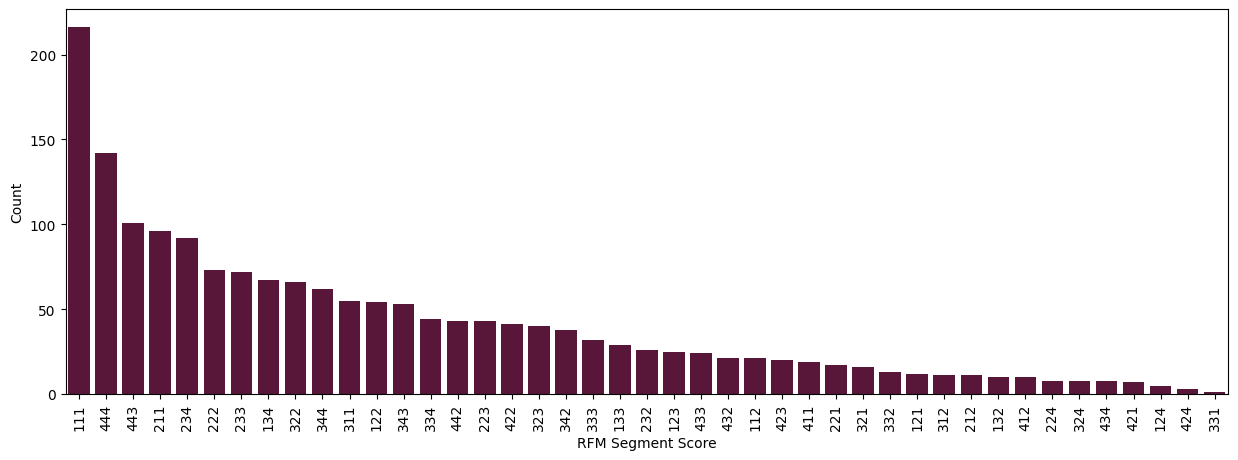

In [160]:
plt.figure(figsize=(15, 5))
sns.countplot(data=rfm_df, x='RFM_segment', order=rfm_df['RFM_segment'].value_counts().index)
plt.xlabel("RFM Segment Score")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

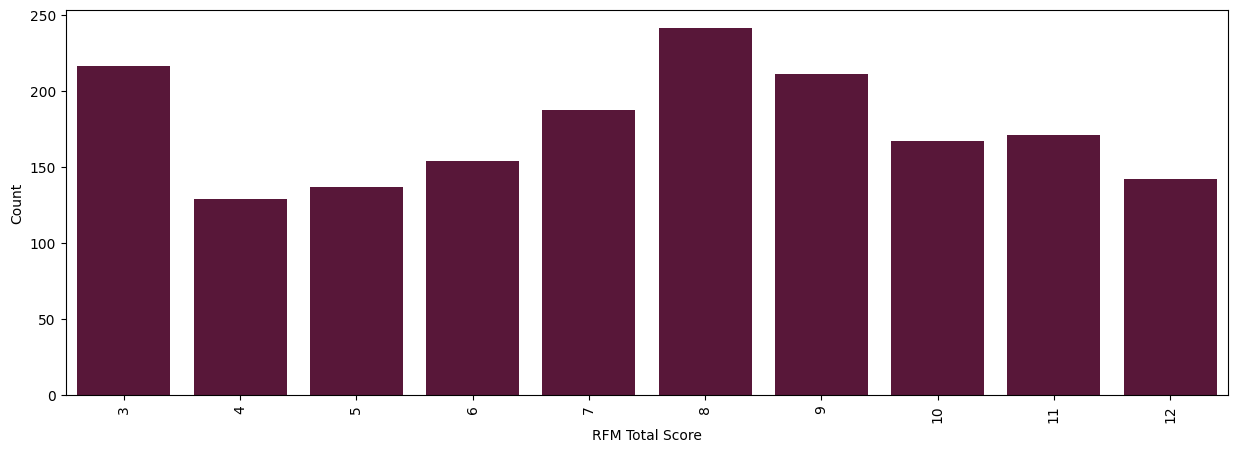

In [166]:
plt.figure(figsize=(15, 5))
sns.countplot(data=rfm_df, x='RFM_score')
plt.xlabel("RFM Total Score")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

<Figure size 1500x500 with 0 Axes>

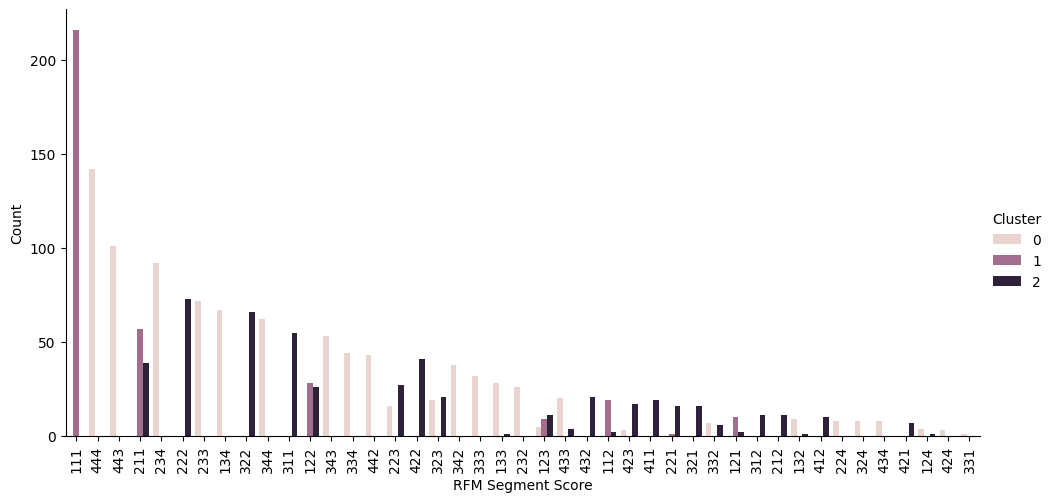

In [164]:
plt.figure(figsize=(15, 5))
sns.catplot(data=rfm_df, x='RFM_segment', hue='Cluster', kind='count', order=rfm_df['RFM_segment'].value_counts().index, height=5, aspect=2)
plt.xticks(rotation=90)
plt.xlabel("RFM Segment Score")
plt.ylabel("Count")
plt.show()

<Figure size 1500x500 with 0 Axes>

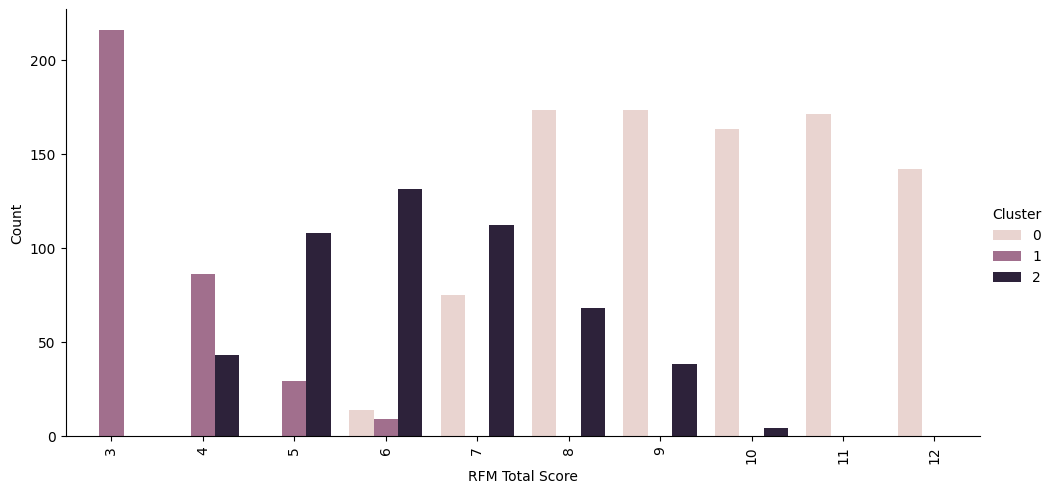

In [165]:
plt.figure(figsize=(15, 5))
sns.catplot(data=rfm_df, x='RFM_score', hue='Cluster', kind='count', height=5, aspect=2)
plt.xticks(rotation=90)
plt.xlabel("RFM Total Score")
plt.ylabel("Count")
plt.show()